# 10. Arsenic

Arsenic poisons more people than any other element in groundwater, and the
reason is thermodynamic rather than geological: the arsenic is already in
the sediment, bound to iron oxides, and **reducing conditions let it go**.

This notebook works out why, and then asks the question that makes arsenic
worth teaching next to selenium: why does reduction immobilise selenium and
mobilise arsenic, when the two sit next to each other in the periodic table
and have superficially similar redox ladders?

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import microbial_thermo as mt
from microbial_thermo.figures import frost_diagram, latimer_diagram, plot_frost, plot_latimer, plot_pourbaix
from microbial_thermo.figures.pourbaix import pourbaix_field, water_stability

warnings.filterwarnings("ignore", category=UserWarning)

## The ladder, and why quoting it needs a pH

In [2]:
for ph in (0.0, 4.0, 7.0, 9.0, 12.0):
    ladder = latimer_diagram("As", pH=ph)
    chain = "  ".join(f"{s.oxidized.backend} –({s.potential:+.3f})→ {s.reduced.backend}" for s in ladder.steps)
    print(f"pH {ph:4.1f}   {chain}")

pH  0.0   H3AsO4(aq) –(+0.574)→ As(OH)3(aq)  As(OH)3(aq) –(+0.248)→ As
pH  4.0   H2AsO4- –(+0.286)→ As(OH)3(aq)  As(OH)3(aq) –(+0.012)→ As
pH  7.0   HAsO4-- –(+0.013)→ As(OH)3(aq)  As(OH)3(aq) –(-0.166)→ As
pH  9.0   HAsO4-- –(-0.224)→ As(OH)3(aq)  As(OH)3(aq) –(-0.284)→ As
pH 12.0   AsO4--- –(-0.508)→ H2AsO3-  H2AsO3- –(-0.517)→ As


The As(V) species changes four times across that range — H₃AsO₄, H₂AsO₄⁻,
HAsO₄²⁻, AsO₄³⁻ — and the potential changes with it. An arsenate potential
quoted without naming the species is not a number, it is three numbers.

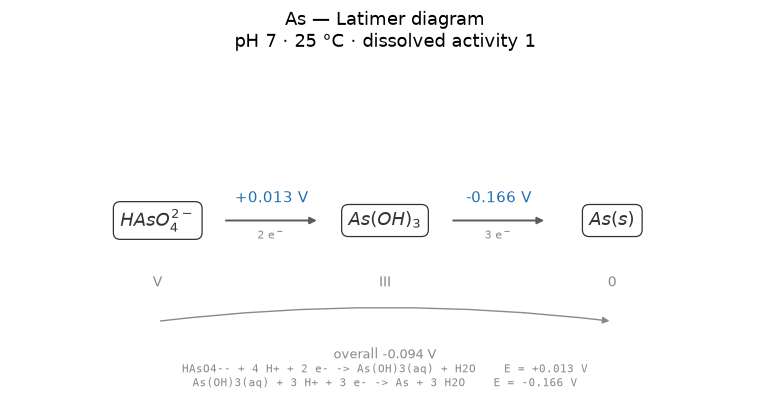

In [3]:
ladder = latimer_diagram("As", pH=7.0)
plot_latimer("As", diagram=ladder, show_half_reactions=True)
plt.show()

## What is stable

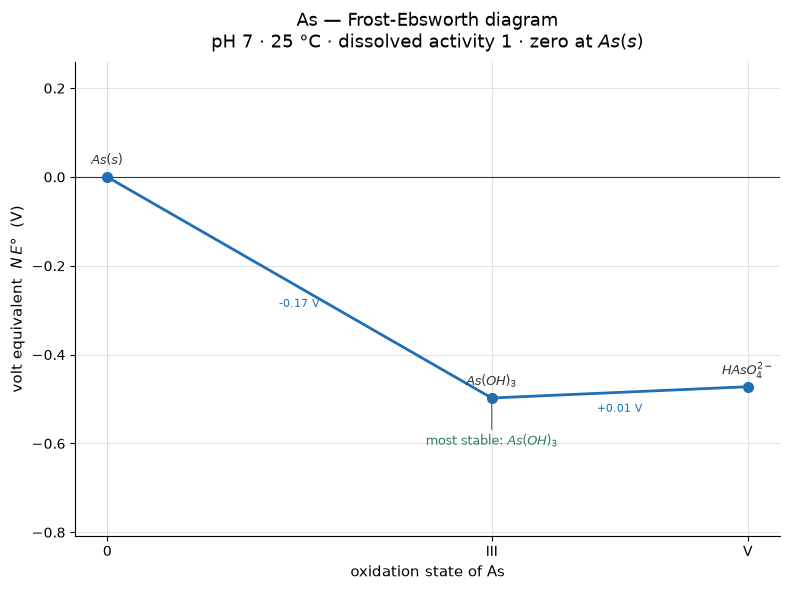

In [4]:
plot_frost("As", pH=7.0, annotate_slopes=True)
plt.show()

In [5]:
frost = frost_diagram("As", pH=7.0)
print("most stable at pH 7:", frost.most_stable.backend)
print("most stable at pH 0:", frost_diagram("As", pH=0.0).most_stable.backend)
print("nothing disproportionates:", frost.disproportionation() == [])

most stable at pH 7: As(OH)3(aq)
most stable at pH 0: As
nothing disproportionates: True


Arsenic's curve is unremarkable — a clean convex chain with no unstable
intermediate. The interesting thing is where the minimum sits: at pH 0 the
element, at pH 7 **arsenite**, a dissolved species.

## Where each form lives

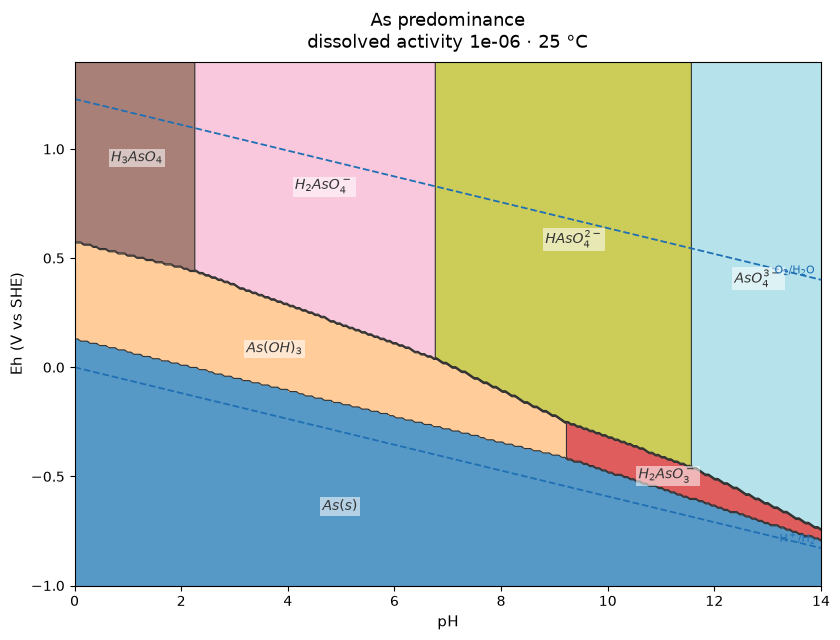

In [6]:
plot_pourbaix("As", figsize=(8.5, 6.5))
plt.show()

## The measurement that matters

How much of the range water can actually reach does each form hold? Only the
band between the two water-stability lines is physically available.

In [7]:
field = pourbaix_field("As", points=241)
ph_axis, upper, lower = water_stability(25.0)

column = int(np.argmin(abs(field.ph - 7.0)))
window = (lower[int(np.argmin(abs(ph_axis - 7.0)))], upper[int(np.argmin(abs(ph_axis - 7.0)))])
print(f"water is stable from {window[0]:+.3f} to {window[1]:+.3f} V at pH 7\n")

previous = None
for row, winner in enumerate(field.winner[:, column]):
    name = field.species[int(winner)]
    if name != previous:
        inside = "inside" if window[0] <= field.eh[row] <= window[1] else "below"
        print(f"  Eh ≥ {field.eh[row]:+.3f} V : {name:14s} ({inside} the water window)")
        previous = name

water is stable from -0.414 to +0.815 V at pH 7

  Eh ≥ -1.000 V : As             (below the water window)
  Eh ≥ -0.280 V : As(OH)3(aq)    (inside the water window)
  Eh ≥ +0.020 V : HAsO4--        (inside the water window)


Elemental arsenic only appears below about −0.28 V, and water itself gives
out at −0.414 V. So As(0) has roughly 130 mV of the water window — a sliver
— and everything above it is **dissolved**: arsenite from −0.28 to +0.02,
arsenate above that.

Now the crucial detail, which the Eh–pH diagram alone does not show:

In [8]:
for name in ("H3AsO4(aq)", "H2AsO4-", "HAsO4--", "As(OH)3(aq)", "H2AsO3-"):
    species = mt.resolve(name)
    print(f"{name:12s} charge {species.charge:+d}")

H3AsO4(aq)   charge +0
H2AsO4-      charge -1
HAsO4--      charge -2
As(OH)3(aq)  charge +0
H2AsO3-      charge -1


**Arsenite at pH 7 is As(OH)₃, and it is neutral.** Arsenate carries a
charge and sorbs strongly to iron-oxide surfaces; uncharged arsenious acid
does not. So reducing an aquifer does two things at once — it dissolves the
iron oxide that was holding the arsenic, and it converts the arsenic to the
form that would not stick to the oxide anyway.

That is the Bengal-delta problem in two sentences, and both of them are on
the diagrams above.

## Who lives on each step

In [9]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
arsenic = [
    "arsenate_respiration_hydrogen",
    "arsenate_respiration_acetate",
    "arsenate_respiration_lactate",
    "arsenite_oxidation_oxygen",
    "arsenite_oxidation_nitrate",
    "arsenite_carbon_fixation",
]
table = mt.energy_table(conditions).set_index("name")
table.loc[arsenic][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
arsenate_respiration_hydrogen,Arsenate respiration with hydrogen,-41.181357,2 H+ + H2(g) + HAsO4-- -> As(OH)3(aq) + H2O
arsenate_respiration_acetate,Arsenate respiration with acetate,-27.220537,1/4 Acetate + 9/4 H+ + HAsO4-- -> 1/2 CO2(aq) ...
arsenate_respiration_lactate,Arsenate respiration with lactate,-42.544295,1/2 Lactate(aq) + 2 H+ + HAsO4-- -> 1/2 Acetat...
arsenite_oxidation_oxygen,Arsenite oxidation with oxygen,-81.543731,As(OH)3(aq) + 1/2 O2(aq) -> HAsO4-- + 2 H+
arsenite_oxidation_nitrate,Arsenite oxidation with nitrate,-38.063603,As(OH)3(aq) + NO3- -> HAsO4-- + 2 H+ + NO2-
arsenite_carbon_fixation,Carbon fixation driven by arsenite oxidation,40.358255,As(OH)3(aq) + 1/2 H2O + 1/2 CO2(aq) -> HAsO4--...


Arsenate respiration is a genuine anaerobic metabolism, and it is the
microbial engine of arsenic release: the organisms are not poisoning anyone
deliberately, they are respiring a perfectly good electron acceptor.

The last row is the striking one. Arsenite-driven carbon fixation is
**endergonic** — it has to be, since arsenite is a poor donor and CO₂ a poor
acceptor — and the organisms that do it are anoxygenic phototrophs paying
the difference with light. Notebook `photoAs` works that budget out.

## One thing worth taking away

Arsenic has no insoluble sink at environmentally reachable potentials.
Every form it takes between the water lines at pH 7 is dissolved. Selenium,
next door, does have one — and notebook 11 measures the difference.